# Modelagem UAVIDS-2025: Detecção de Intrusão em Redes UAV

Este notebook cobre as fases **Data Preparation**, **Modeling** e **Evaluation** do ciclo CRISP-DM:

1. Pipeline sklearn com ColumnTransformer
2. Comparativo de 3 modelos no MLflow Tracking com CV 5-fold
3. Tuning do vencedor com RandomizedSearchCV
4. Avaliação final com métricas por classe e matriz de confusão
5. Model Registry com alias `@production`

In [1]:
# ============================================================
# CONFIGURACAO MLFLOW
# ============================================================
import mlflow
from pathlib import Path

# Garante que mlruns/ existe na raiz do projeto (cwd do VS Code)
Path('mlruns').mkdir(exist_ok=True)

# URI absoluta cross-platform (evita problemas com file:./mlruns no Windows)
_mlruns_uri = Path('mlruns').resolve().as_uri()
mlflow.set_tracking_uri(_mlruns_uri)
mlflow.set_experiment('uavids2025_ids')

print(f'Tracking URI: {mlflow.get_tracking_uri()}')
print('Experimento:  uavids2025_ids')

Tracking URI: file:///C:/Users/User/Documents/datasci/notebooks/mlruns
Experimento:  uavids2025_ids


c:\Users\User\Documents\datasci\.venv\Lib\site-packages\mlflow\tracking\_tracking_service\utils.py:184: FutureWarning: The filesystem tracking backend (e.g., './mlruns') is deprecated as of February 2026. Consider transitioning to a database backend (e.g., 'sqlite:///mlflow.db') to take advantage of the latest MLflow features. See https://mlflow.org/docs/latest/self-hosting/migrate-from-file-store for migration guidance.
  return FileStore(store_uri, store_uri)


In [2]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import (
    StratifiedKFold, cross_validate, RandomizedSearchCV, train_test_split
)
from sklearn.metrics import (
    f1_score, classification_report,
    confusion_matrix, ConfusionMatrixDisplay
)
from sklearn.preprocessing import FunctionTransformer

import xgboost as xgb
import lightgbm as lgb
import mlflow
from mlflow.tracking import MlflowClient

sns.set_theme(style='whitegrid', palette='Set2')
plt.rcParams['figure.dpi'] = 120

RANDOM_STATE = 42
DATASET_PATH = 'data/raw/UAVIDS-2025.csv'
EXPERIMENT_NAME = 'uavids2025_ids'
MODEL_NAME = 'previsor_uav_ids'

# Paleta semantica consistente com EDA
PALETTE = {
    'Normal Traffic':   '#2196F3',
    'Blackhole Attack': '#F44336',
    'Flooding Attack':  '#FF9800',
    'Sybil Attack':     '#9C27B0',
    'Wormhole Attack':  '#E91E63',
}
CLASSES_ORDER = list(PALETTE.keys())

print('Setup concluido.')
print(f'XGBoost version:  {xgb.__version__}')
print(f'LightGBM version: {lgb.__version__}')
print(f'MLflow version:   {mlflow.__version__}')

Setup concluido.
XGBoost version:  2.0.3
LightGBM version: 4.6.0
MLflow version:   3.12.0


## 1. Carregamento e Preparação dos Dados

In [3]:
df = pd.read_csv(DATASET_PATH)

# --- Feature engineering---
eps_small = 1e-9
eps_hop   = 1.0

df['loss_ratio']         = df['LostPackets']     / (df['TxPackets']        + eps_small)
df['tx_efficiency']      = df['RxBytes']          / (df['TxBytes']          + eps_small)
df['throughput_per_hop'] = df['Throughput/Kbps']  / (df['AverageHopCount']  + eps_hop)

# --- Definição de features ---
FEATURES = [
    # Connection
    'FlowDuration/s', 'SrcPort', 'DstPort',
    # Traffic Volume
    'TxPackets', 'RxPackets', 'LostPackets',
    'TxBytes', 'RxBytes',
    'TxPacketRate/s', 'RxPacketRate/s',
    'TxByteRate/s', 'RxByteRate/s',
    'MeanPacketSize',
    # Performance
    'MeanDelay/s', 'MeanJitter/s',
    'Throughput/Kbps', 'PacketDropRate', 'AverageHopCount',
    # Derivadas (EDA)
    'loss_ratio', 'tx_efficiency', 'throughput_per_hop',
]

TARGET = 'label'

X = df[FEATURES]
y = df[TARGET]

print(f'Shape X: {X.shape}')
print(f'Classes: {y.nunique()} -> {sorted(y.unique())}')
print(f'\nDistribuição do alvo:')
print(y.value_counts().to_string())

Shape X: (122171, 21)
Classes: 5 -> ['Blackhole Attack', 'Flooding Attack', 'Normal Traffic', 'Sybil Attack', 'Wormhole Attack']

Distribuição do alvo:
label
Normal Traffic      26172
Blackhole Attack    26110
Wormhole Attack     26086
Sybil Attack        24077
Flooding Attack     19726


## 2. Split Estratificado Treino / Teste

In [4]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,
    stratify=y,
    random_state=RANDOM_STATE
)

print(f'Treino: {X_train.shape[0]:,} amostras')
print(f'Teste:  {X_test.shape[0]:,} amostras')
print()
print('Distribuição treino (%):')
print((y_train.value_counts(normalize=True) * 100).round(1).to_string())
print()
print('Distribuição teste (%):')
print((y_test.value_counts(normalize=True) * 100).round(1).to_string())

Treino: 97,736 amostras
Teste:  24,435 amostras

Distribuição treino (%):
label
Normal Traffic      21.4
Blackhole Attack    21.4
Wormhole Attack     21.4
Sybil Attack        19.7
Flooding Attack     16.1

Distribuição teste (%):
label
Normal Traffic      21.4
Blackhole Attack    21.4
Wormhole Attack     21.4
Sybil Attack        19.7
Flooding Attack     16.1


## 3. Pipeline sklearn

In [5]:
def clip_packet_drop_rate(X):
    """Clip PacketDropRate para [0, 1]. 81 registros têm valor > 1 (artefato NS-3)."""
    X = X.copy()
    if hasattr(X, 'columns') and 'PacketDropRate' in X.columns:
        idx = list(X.columns).index('PacketDropRate')
        X.iloc[:, idx] = X.iloc[:, idx].clip(0, 1)
    elif hasattr(X, 'shape'):
        # numpy array - PacketDropRate é a coluna 16 (0-indexed) na lista FEATURES
        pdr_idx = FEATURES.index('PacketDropRate')
        X[:, pdr_idx] = np.clip(X[:, pdr_idx], 0, 1)
    return X


def construir_preprocessador():
    """Retorna um ColumnTransformer com imputer + scaler para todas as features."""
    transformador = ColumnTransformer(
        transformers=[
            ('num', Pipeline([
                ('imputer', SimpleImputer(strategy='median')),
                ('scaler',  StandardScaler()),
            ]), FEATURES),
        ],
        remainder='drop'
    )
    return transformador


def construir_pipeline(classificador):
    """Monta o Pipeline completo: clip -> preprocessador -> classificador."""
    return Pipeline([
        ('clip',  FunctionTransformer(clip_packet_drop_rate, validate=False)),
        ('prep',  construir_preprocessador()),
        ('clf',   classificador),
    ])


# Verificar que o pipeline constrói sem erro
pipe_teste = construir_pipeline(LogisticRegression(max_iter=100))
print('Pipeline construído com sucesso.')
print(pipe_teste)

Pipeline construído com sucesso.
Pipeline(steps=[('clip',
                 FunctionTransformer(func=<function clip_packet_drop_rate at 0x000001E4160CF6A0>)),
                ('prep',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['FlowDuration/s', 'SrcPort',
                                                   'DstPort', 'TxPackets',
                                                   'RxPackets', 'LostPackets',
                                                   'TxBytes', 'RxBytes',
                                                   'TxPacketRate/s',
                                       

## 4. Validação Cruzada

In [6]:
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

# --- Definicao dos 4 modelos ---
MODELOS = {
    'LogisticRegression': LogisticRegression(
        max_iter=1000,
        class_weight='balanced',
        solver='lbfgs',
        multi_class='multinomial',
        random_state=RANDOM_STATE,
    ),
    'RandomForest': RandomForestClassifier(
        n_estimators=300,
        class_weight='balanced_subsample',
        n_jobs=-1,
        random_state=RANDOM_STATE,
    ),
    'XGBoost': xgb.XGBClassifier(
        n_estimators=300,
        learning_rate=0.1,
        max_depth=6,
        subsample=0.8,
        colsample_bytree=0.8,
        eval_metric='mlogloss',
        use_label_encoder=False,
        random_state=RANDOM_STATE,
    ),
    'LightGBM': lgb.LGBMClassifier(
        n_estimators=300,
        learning_rate=0.1,
        max_depth=6,
        subsample=0.8,
        colsample_bytree=0.8,
        class_weight='balanced',
        random_state=RANDOM_STATE,
        verbose=-1,
    ),
}

print('\nModelos configurados:')
for nome in MODELOS:
    print(f'  - {nome}')


Modelos configurados:
  - LogisticRegression
  - RandomForest
  - XGBoost
  - LightGBM


**Função:** Treinar e comparar os 3 modelos com validação cruzada, registrando cada run no MLflow Tracking.

**Método:** `cross_validate()` com `StratifiedKFold(n_splits=5)` a estratificação garante que cada fold preserve a proporção das classes (especialmente Flooding com 16%). O pipeline completo (clip -> scaler -> classificador) é ajustado nos folds de treino e avaliado no fold de validação, sem qualquer contato com o conjunto de teste holdout. Métricas e o pipeline serializado são logados no MLflow via `log_param`, `log_metric` e `log_model`.

In [7]:
resultados_cv = {}

# XGBoost precisa de labels numericas
le = LabelEncoder()
y_train_enc = le.fit_transform(y_train)
y_test_enc  = le.transform(y_test)
print(f'Classes codificadas: {dict(zip(le.classes_, le.transform(le.classes_)))}')
print()

# Pre-processamento do primeiro fold para curvas de aprendizado por round
fold_idxs = list(skf.split(X_train, y_train_enc))
lc_tr_idx, lc_val_idx = fold_idxs[0]
X_lc_tr  = X_train.iloc[lc_tr_idx]
X_lc_val = X_train.iloc[lc_val_idx]
y_lc_tr_enc  = y_train_enc[lc_tr_idx]
y_lc_val_enc = y_train_enc[lc_val_idx]
y_lc_tr_str  = y_train.iloc[lc_tr_idx]
y_lc_val_str = y_train.iloc[lc_val_idx]
prep_lc = construir_preprocessador()
X_lc_tr_prep  = prep_lc.fit_transform(clip_packet_drop_rate(X_lc_tr))
X_lc_val_prep = prep_lc.transform(clip_packet_drop_rate(X_lc_val))

for nome, clf in MODELOS.items():
    print(f'Treinando {nome}...')

    y_cv = y_train_enc if nome == 'XGBoost' else y_train

    pipe = construir_pipeline(clf)

    cv_results = cross_validate(
        pipe, X_train, y_cv,
        cv=skf,
        scoring={
            'f1_macro': 'f1_macro',
            'accuracy': 'accuracy',
        },
        return_train_score=True,
        n_jobs=1,
    )

    f1_mean       = cv_results['test_f1_macro'].mean()
    f1_std        = cv_results['test_f1_macro'].std()
    acc_mean      = cv_results['test_accuracy'].mean()
    acc_std       = cv_results['test_accuracy'].std()
    train_f1_mean = cv_results['train_f1_macro'].mean()
    train_f1_std  = cv_results['train_f1_macro'].std()
    gap_f1        = train_f1_mean - f1_mean

    resultados_cv[nome] = {
        'f1_macro_mean':       f1_mean,
        'f1_macro_std':        f1_std,
        'accuracy_mean':       acc_mean,
        'accuracy_std':        acc_std,
        'train_f1_macro_mean': train_f1_mean,
        'train_f1_macro_std':  train_f1_std,
        'gap_f1_macro':        gap_f1,
        'f1_folds':            cv_results['test_f1_macro'],
        'train_f1_folds':      cv_results['train_f1_macro'],
        'fit_time_mean':       cv_results['fit_time'].mean(),
        'pipe':                pipe,
        'y_cv':                y_cv,
    }

    with mlflow.start_run(run_name=nome):
        params = clf.get_params()
        for k, v in params.items():
            mlflow.log_param(k, v)
        mlflow.log_param('cv_folds', 5)
        mlflow.log_param('features_count', len(FEATURES))
        mlflow.log_param('class_balance_strategy', 'class_weight=balanced')

        mlflow.log_metric('f1_macro_cv_mean',       f1_mean)
        mlflow.log_metric('f1_macro_cv_std',        f1_std)
        mlflow.log_metric('accuracy_cv_mean',       acc_mean)
        mlflow.log_metric('accuracy_cv_std',        acc_std)
        mlflow.log_metric('fit_time_mean_s',        cv_results['fit_time'].mean())
        mlflow.log_metric('train_f1_macro_cv_mean', train_f1_mean)
        mlflow.log_metric('train_f1_macro_cv_std',  train_f1_std)
        mlflow.log_metric('gap_f1_macro',           gap_f1)

        for i, (tr, val) in enumerate(zip(cv_results['train_f1_macro'], cv_results['test_f1_macro'])):
            mlflow.log_metric('train_f1_macro_fold', tr,  step=i)
            mlflow.log_metric('val_f1_macro_fold',   val, step=i)

        folds = np.arange(1, 6)
        fig, ax = plt.subplots(figsize=(7, 4))
        ax.plot(folds, cv_results['train_f1_macro'], 'o-',  color='#2196F3', label='Treino')
        ax.plot(folds, cv_results['test_f1_macro'],  's--', color='#F44336', label='Validacao')
        ax.fill_between(
            folds,
            cv_results['train_f1_macro'],
            cv_results['test_f1_macro'],
            alpha=0.15, color='#FF9800', label=f'Gap medio: {gap_f1:.4f}',
        )
        ax.set_xlabel('Fold')
        ax.set_ylabel('F1-macro')
        ax.set_title(f'Train vs. Validacao por Fold - {nome}', fontweight='bold')
        ax.legend()
        ax.set_ylim(
            max(0, min(cv_results['test_f1_macro'].min(), cv_results['train_f1_macro'].min()) - 0.02),
            1.01,
        )
        plt.tight_layout()
        mlflow.log_figure(fig, f'overfitting_{nome}.png')
        plt.close(fig)

        if nome in ('XGBoost', 'LightGBM'):
            clf_lc = clf.__class__(**clf.get_params())
            if nome == 'XGBoost':
                clf_lc.fit(
                    X_lc_tr_prep, y_lc_tr_enc,
                    eval_set=[(X_lc_tr_prep, y_lc_tr_enc), (X_lc_val_prep, y_lc_val_enc)],
                    verbose=False,
                )
                evals      = clf_lc.evals_result()
                train_loss = evals['validation_0']['mlogloss']
                val_loss   = evals['validation_1']['mlogloss']
                metric_nm  = 'mlogloss'
            else:
                evals_res = {}
                clf_lc.fit(
                    X_lc_tr_prep, y_lc_tr_str,
                    eval_set=[(X_lc_tr_prep, y_lc_tr_str), (X_lc_val_prep, y_lc_val_str)],
                    callbacks=[lgb.record_evaluation(evals_res)],
                )
                keys_lc    = list(evals_res.keys())
                metric_nm  = list(evals_res[keys_lc[0]].keys())[0]
                train_loss = evals_res[keys_lc[0]][metric_nm]
                val_loss   = evals_res[keys_lc[1]][metric_nm]

            for i, (tr, val) in enumerate(zip(train_loss, val_loss)):
                mlflow.log_metric(f'train_{metric_nm}', tr,  step=i)
                mlflow.log_metric(f'val_{metric_nm}',   val, step=i)
            best_round = int(val_loss.index(min(val_loss))) + 1
            mlflow.log_metric('best_round_early_stop', best_round)

            rounds = range(1, len(train_loss) + 1)
            fig_lc, ax_lc = plt.subplots(figsize=(9, 4))
            ax_lc.plot(rounds, train_loss, color='#2196F3', linewidth=1.2, label='Treino')
            ax_lc.plot(rounds, val_loss,   color='#F44336', linewidth=1.2, label='Validacao')
            ax_lc.axvline(best_round, color='#4CAF50', linestyle='--', linewidth=1.2,
                          label=f'Melhor round: {best_round}')
            ax_lc.set_xlabel('Boosting Round')
            ax_lc.set_ylabel(metric_nm)
            ax_lc.set_title(f'Curva de Aprendizado por Round - {nome}', fontweight='bold')
            ax_lc.legend()
            plt.tight_layout()
            mlflow.log_figure(fig_lc, 'learning_curve_by_round.png')
            plt.close(fig_lc)

        pipe_para_log = construir_pipeline(clf)
        pipe_para_log.fit(X_train, y_cv)
        mlflow.sklearn.log_model(pipe_para_log, name='model')

    print(f'  Train F1-macro: {train_f1_mean:.4f} +/- {train_f1_std:.4f}')
    print(f'  Val   F1-macro: {f1_mean:.4f} +/- {f1_std:.4f}  |  Gap: {gap_f1:.4f}')
    print(f'  Accuracy CV:    {acc_mean:.4f} +/- {acc_std:.4f}')
    print(f'  Fit time medio: {cv_results["fit_time"].mean():.1f}s')
    print()


Classes codificadas: {'Blackhole Attack': 0, 'Flooding Attack': 1, 'Normal Traffic': 2, 'Sybil Attack': 3, 'Wormhole Attack': 4}

Treinando LogisticRegression...


2026/05/27 13:00:32 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


  Train F1-macro: 0.8214 +/- 0.0004
  Val   F1-macro: 0.8216 +/- 0.0025  |  Gap: -0.0003
  Accuracy CV:    0.8190 +/- 0.0026
  Fit time medio: 4.5s

Treinando RandomForest...


2026/05/27 13:01:25 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


  Train F1-macro: 1.0000 +/- 0.0000
  Val   F1-macro: 0.9529 +/- 0.0010  |  Gap: 0.0471
  Accuracy CV:    0.9502 +/- 0.0010
  Fit time medio: 6.7s

Treinando XGBoost...


2026/05/27 13:02:02 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


  Train F1-macro: 0.9791 +/- 0.0003
  Val   F1-macro: 0.9566 +/- 0.0007  |  Gap: 0.0225
  Accuracy CV:    0.9542 +/- 0.0007
  Fit time medio: 3.9s

Treinando LightGBM...


2026/05/27 13:02:41 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


  Train F1-macro: 0.9816 +/- 0.0004
  Val   F1-macro: 0.9563 +/- 0.0009  |  Gap: 0.0253
  Accuracy CV:    0.9539 +/- 0.0009
  Fit time medio: 3.1s



## 5. Comparativo dos Modelos

In [8]:
# Tabela comparativa — Experimento principal (5 classes)
tabela = pd.DataFrame([
    {
        'Modelo':          nome,
        'F1-val (media)':  f'{v["f1_macro_mean"]:.4f}',
        'F1-val (std)':    f'{v["f1_macro_std"]:.4f}',
        'F1-treino':       f'{v["train_f1_macro_mean"]:.4f}',
        'Gap':             f'{v["gap_f1_macro"]:.4f}',
        'Accuracy':        f'{v["accuracy_mean"]:.4f}',
        'Fit time (s)':    f'{v["fit_time_mean"]:.1f}',
    }
    for nome, v in resultados_cv.items()
])

print('=' * 85)
print('COMPARATIVO DE MODELOS — CV 5-fold | Experimento: uavids2025_ids (5 classes)')
print('=' * 85)
print(tabela.to_string(index=False))
print('=' * 85)

vencedor_nome = max(resultados_cv, key=lambda n: resultados_cv[n]['f1_macro_mean'])
vencedor_f1   = resultados_cv[vencedor_nome]['f1_macro_mean']
vencedor_std  = resultados_cv[vencedor_nome]['f1_macro_std']
print(f'\nVencedor: {vencedor_nome}  (F1-macro = {vencedor_f1:.4f} +/- {vencedor_std:.4f})')


COMPARATIVO DE MODELOS — CV 5-fold | Experimento: uavids2025_ids (5 classes)
            Modelo F1-val (media) F1-val (std) F1-treino     Gap Accuracy Fit time (s)
LogisticRegression         0.8216       0.0025    0.8214 -0.0003   0.8190          4.5
      RandomForest         0.9529       0.0010    1.0000  0.0471   0.9502          6.7
           XGBoost         0.9566       0.0007    0.9791  0.0225   0.9542          3.9
          LightGBM         0.9563       0.0009    0.9816  0.0253   0.9539          3.1

Vencedor: XGBoost  (F1-macro = 0.9566 +/- 0.0007)


**Função:** Visualizar o comparativo de F1-macro dos 3 modelos destacando o vencedor.

**Método:** Gráfico de barras com barras de erro (`yerr=std`) usando `ax.bar()`. As barras de erro mostram o desvio padrão entre os 5 folds um modelo com F1 alto mas desvio alto pode ser menos confiável que outro ligeiramente inferior mas mais estável.

In [9]:
nomes     = list(resultados_cv.keys())
f1s       = [resultados_cv[n]['f1_macro_mean']       for n in nomes]
train_f1s = [resultados_cv[n]['train_f1_macro_mean'] for n in nomes]
stds      = [resultados_cv[n]['f1_macro_std']         for n in nomes]
gaps      = [resultados_cv[n]['gap_f1_macro']         for n in nomes]
cores     = ['#4CAF50' if n == vencedor_nome else '#90A4AE' for n in nomes]

with mlflow.start_run(run_name='comparativo_modelos'):
    # --- Barras: F1-macro validação ---
    fig, ax = plt.subplots(figsize=(7, 5))
    bars = ax.bar(nomes, f1s, yerr=stds, capsize=6,
                  color=cores, alpha=0.88, edgecolor='white', linewidth=1.2,
                  error_kw={'linewidth': 1.5, 'ecolor': '#333'})
    for bar, f1, std in zip(bars, f1s, stds):
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height() + std + 0.003,
            f'{f1:.4f}\n±{std:.4f}',
            ha='center', va='bottom', fontsize=10, fontweight='bold',
        )
    ax.set_ylabel('F1-macro (CV 5-fold)', fontsize=11)
    ax.set_title('Comparativo de Modelos - UAVIDS-2025\nVerde = vencedor', fontsize=12, fontweight='bold')
    ax.set_ylim(min(f1s) - 0.05, 1.02)
    plt.tight_layout()
    mlflow.log_figure(fig, 'comparativo_modelos_barras.png')
    plt.close(fig)

    # --- Boxplot dos folds ---
    fig, ax = plt.subplots(figsize=(7, 5))
    fold_data = [resultados_cv[n]['f1_folds'] for n in nomes]
    bp = ax.boxplot(fold_data, labels=nomes, patch_artist=True,
                    medianprops={'color': 'black', 'linewidth': 2})
    for patch, cor in zip(bp['boxes'], cores):
        patch.set_facecolor(cor)
        patch.set_alpha(0.7)
    ax.set_ylabel('F1-macro por fold', fontsize=11)
    ax.set_title('Distribuição do F1-macro nos 5 Folds', fontsize=12, fontweight='bold')
    plt.tight_layout()
    mlflow.log_figure(fig, 'comparativo_modelos_boxplot.png')
    plt.close(fig)

    # --- Train vs. Validação agrupado (diagnóstico de overfitting) ---
    fig, ax = plt.subplots(figsize=(8, 5))
    x = np.arange(len(nomes))
    w = 0.35
    ax.bar(x - w/2, train_f1s, w, label='Treino',    color='#2196F3', alpha=0.85)
    ax.bar(x + w/2, f1s,       w, label='Validação', color='#F44336', alpha=0.85)
    for i, (tr, val, gap) in enumerate(zip(train_f1s, f1s, gaps)):
        ax.text(i, max(tr, val) + 0.005, f'gap={gap:.4f}', ha='center', fontsize=9, color='#333')
    ax.set_xticks(x)
    ax.set_xticklabels(nomes)
    ax.set_ylabel('F1-macro (média CV 5-fold)', fontsize=11)
    ax.set_title('Train vs. Validação - Diagnóstico de Overfitting', fontsize=12, fontweight='bold')
    ax.legend()
    ax.set_ylim(min(f1s + train_f1s) - 0.05, 1.04)
    plt.tight_layout()
    mlflow.log_figure(fig, 'overfitting_gap_comparativo.png')
    plt.close(fig)

    # Métricas de resumo da comparação
    for nome in nomes:
        mlflow.log_metric(f'{nome}_f1_val',   resultados_cv[nome]['f1_macro_mean'])
        mlflow.log_metric(f'{nome}_f1_train', resultados_cv[nome]['train_f1_macro_mean'])
        mlflow.log_metric(f'{nome}_gap',      resultados_cv[nome]['gap_f1_macro'])

print('Gráficos logados no MLflow (run: comparativo_modelos):')
print('  - comparativo_modelos_barras.png')
print('  - comparativo_modelos_boxplot.png')
print('  - overfitting_gap_comparativo.png')

Gráficos logados no MLflow (run: comparativo_modelos):
  - comparativo_modelos_barras.png
  - comparativo_modelos_boxplot.png
  - overfitting_gap_comparativo.png


**Análise do gráfico (Comparativo de Modelos - F1-macro CV 5-fold):**

- **LogisticRegression:** 0,8216 (+/-0,0024) - 13 pontos percentuais abaixo dos demais. Modelo linear não captura a fronteira BH<->WH.
- **RandomForest:** 0,9529 (+/-0,0010) - salto enorme, confirma que o problema é essencialmente não-linear.
- **XGBoost:** 0,9564 (+/-0,0008) - **vencedor** (barra verde). Margem pequena sobre o RF (~0,35 ponto percentual), mas com desvio padrão ainda menor (mais estável).
- As barras de erro são minúsculas nos três modelos, o que indica scores muito consistentes entre os 5 folds. O ranking não é fruto de variação aleatória.
- Decisão: XGBoost é o vencedor por margem reduzida mas estável. Segue para tuning de hiperparâmetros.

**Função:** Analisar a distribuição dos scores nos 5 folds para avaliar estabilidade além do valor médio.

**Método:** `ax.boxplot()` com os 5 scores de cada modelo. Complementa o gráfico de barras um modelo com pequena variância entre folds (boxplot estreito) é mais confiável em produção do que um com alta variância, mesmo que a média seja similar.

In [10]:
# Boxplot integrado na run 'comparativo_modelos' da célula anterior.
print('Boxplot disponível no MLflow: run comparativo_modelos -> Artifacts -> comparativo_modelos_boxplot.png')

Boxplot disponível no MLflow: run comparativo_modelos -> Artifacts -> comparativo_modelos_boxplot.png


**Análise do gráfico (Distribuição do F1-macro nos 5 Folds):**

- **LogisticRegression:** caixa centrada em ~0,822, faixa entre ~0,818 e 0,825. Estável mas em um patamar baixo.
- **RandomForest:** caixa praticamente colapsada em ~0,953 (faixa ~0,952-0,954). Variação inter-fold quase nula.
- **XGBoost:** caixa também colapsada em ~0,956 (faixa ~0,9555-0,957). Levemente acima do RF em todos os folds.
- Os três boxplots são minúsculos (IQR < 0,01), indicando que o dataset é internamente consistente - não há folds "difíceis" ou "fáceis".
- Conclusão: a vantagem do XGBoost sobre o RF (~0,35 ponto percentual) é uniforme nos 5 folds, não um efeito de sorte em algum split específico. A escolha do vencedor é robusta.

## 6. Tuning do Vencedor - RandomizedSearchCV

In [11]:
from scipy.stats import randint, uniform

# Espaços de busca por modelo
PARAM_SPACES = {
    'LogisticRegression': {
        'clf__C':        uniform(0.01, 10),
        'clf__solver':   ['lbfgs', 'saga'],
        'clf__max_iter': [500, 1000, 2000],
    },
    'RandomForest': {
        'clf__n_estimators':      randint(200, 600),
        'clf__max_depth':         [None, 10, 20, 30],
        'clf__min_samples_split': randint(2, 10),
        'clf__min_samples_leaf':  randint(1, 5),
        'clf__max_features':      ['sqrt', 'log2', 0.5],
    },
    'XGBoost': {
        'clf__n_estimators':     randint(200, 600),
        'clf__max_depth':        randint(4, 10),
        'clf__learning_rate':    uniform(0.01, 0.2),
        'clf__subsample':        uniform(0.6, 0.4),
        'clf__colsample_bytree': uniform(0.6, 0.4),
        'clf__min_child_weight': randint(1, 6),
        'clf__gamma':            uniform(0, 0.5),
    },
    'LightGBM': {
        'clf__n_estimators':      randint(200, 600),
        'clf__max_depth':         randint(4, 10),
        'clf__learning_rate':     uniform(0.01, 0.2),
        'clf__subsample':         uniform(0.6, 0.4),
        'clf__colsample_bytree':  uniform(0.6, 0.4),
        'clf__num_leaves':        randint(20, 60),
        'clf__min_child_samples': randint(10, 50),
    },
}

print(f'Tuning do vencedor: {vencedor_nome}')
print(f'Espaço de busca: {list(PARAM_SPACES[vencedor_nome].keys())}')

Tuning do vencedor: XGBoost
Espaço de busca: ['clf__n_estimators', 'clf__max_depth', 'clf__learning_rate', 'clf__subsample', 'clf__colsample_bytree', 'clf__min_child_weight', 'clf__gamma']


**Função:** Otimizar os hiperparâmetros do XGBoost para maximizar o F1-macro no conjunto de treino.

**Método:** `RandomizedSearchCV` com `n_iter=10` e `cv=5` preferido ao `GridSearchCV` porque o espaço de hiperparâmetros do XGBoost tem 7 dimensões, tornando a busca exaustiva inviável. Distribuições contínuas (`uniform`, `randint`) cobrem o espaço de forma mais eficiente que um grid fixo. O `cv=5` é o mesmo da fase de comparação, garantindo consistência.

**Bibliotecas:** `sklearn.model_selection (RandomizedSearchCV)`, `scipy.stats`

In [12]:
clf_vencedor = MODELOS[vencedor_nome]
y_tune = resultados_cv[vencedor_nome]['y_cv']

pipe_tune = construir_pipeline(clf_vencedor)

rscv = RandomizedSearchCV(
    pipe_tune,
    param_distributions=PARAM_SPACES[vencedor_nome],
    n_iter=10,
    cv=skf,
    scoring='f1_macro',
    refit=True,
    n_jobs=1,
    random_state=RANDOM_STATE,
    verbose=1,
)

print(f'Iniciando RandomizedSearchCV (n_iter=50, cv=5)...')
rscv.fit(X_train, y_tune)

best_f1  = rscv.best_score_
best_params = rscv.best_params_

print(f'\nMelhor F1-macro (CV): {best_f1:.4f}')
print(f'Melhores parâmetros:')
for k, v in best_params.items():
    print(f'  {k}: {v}')

Iniciando RandomizedSearchCV (n_iter=50, cv=5)...
Fitting 5 folds for each of 10 candidates, totalling 50 fits

Melhor F1-macro (CV): 0.9558
Melhores parâmetros:
  clf__colsample_bytree: 0.6399899663272012
  clf__gamma: 0.22962444598293358
  clf__learning_rate: 0.07674172222780437
  clf__max_depth: 6
  clf__min_child_weight: 5
  clf__n_estimators: 457
  clf__subsample: 0.8887995089067299


**Função:** Persistir o pipeline tunado no MLflow Tracking e registrá-lo no Model Registry como versão 1.

**Método:** `mlflow.sklearn.log_model(..., registered_model_name=MODEL_NAME)` salva o pipeline **completo** (pré-processamento + classificador), não apenas o estimador. Isso garante que o endpoint de produção aplique exatamente as mesmas transformações usadas no treino, eliminando risco de data leakage em inferência.

**Bibliotecas:** `mlflow.sklearn`, `mlflow.tracking (MlflowClient)`

In [13]:
# Logar tuning no MLflow
with mlflow.start_run(run_name=f'{vencedor_nome}_tuned'):
    mlflow.log_param('tuning_method', 'RandomizedSearchCV')
    mlflow.log_param('n_iter', 10)
    mlflow.log_param('cv_folds', 5)
    mlflow.log_param('scoring', 'f1_macro')

    for k, v in best_params.items():
        mlflow.log_param(k, v)

    mlflow.log_metric('f1_macro_cv_best', best_f1)

    # Logar o pipeline tunado completo
    mlflow.sklearn.log_model(
        rscv.best_estimator_,
        name='model',
        registered_model_name=MODEL_NAME,
    )

    run_id_tuned = mlflow.active_run().info.run_id

print(f'Run ID do modelo tunado: {run_id_tuned}')
print(f'Modelo registrado como: {MODEL_NAME}')

2026/05/27 13:06:53 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


Run ID do modelo tunado: 3c7c1701abd147239455c42389c8bd9f
Modelo registrado como: previsor_uav_ids


Registered model 'previsor_uav_ids' already exists. Creating a new version of this model...
Created version '2' of model 'previsor_uav_ids'.


## 7. Avaliação Final no Conjunto de Teste

In [14]:
modelo_final = rscv.best_estimator_

# Predição no conjunto de teste
y_pred_enc = modelo_final.predict(X_test)

# Converter de volta para strings se necessário (XGBoost retorna inteiros)
if vencedor_nome == 'XGBoost':
    y_pred = le.inverse_transform(y_pred_enc)
    y_test_str = y_test.values
else:
    y_pred = y_pred_enc
    y_test_str = y_test.values

f1_teste = f1_score(y_test_str, y_pred, average='f1_macro' if False else 'macro')
acc_teste = (y_pred == y_test_str).mean()

print('=' * 60)
print(f'AVALIAÇÃO FINAL - CONJUNTO DE TESTE HOLDOUT')
print(f'Modelo: {vencedor_nome} (tunado)')
print('=' * 60)
print(f'F1-macro:  {f1_teste:.4f}')
print(f'Accuracy:  {acc_teste:.4f}')
print()
print('Classification Report:')
print(classification_report(y_test_str, y_pred, digits=4,
                             target_names=CLASSES_ORDER))

AVALIAÇÃO FINAL - CONJUNTO DE TESTE HOLDOUT
Modelo: XGBoost (tunado)
F1-macro:  0.9574
Accuracy:  0.9550

Classification Report:
                  precision    recall  f1-score   support

  Normal Traffic     0.9505    0.8642    0.9053      5222
Blackhole Attack     0.9949    0.9881    0.9915      3945
 Flooding Attack     0.9912    0.9918    0.9915      5235
    Sybil Attack     0.9928    0.9975    0.9951      4816
 Wormhole Attack     0.8658    0.9446    0.9035      5217

        accuracy                         0.9550     24435
       macro avg     0.9590    0.9572    0.9574     24435
    weighted avg     0.9566    0.9550    0.9550     24435



**Função:** Avaliar onde o modelo erra no conjunto de teste holdout, com foco na confusão entre classes.

**Método:** `confusion_matrix(normalize='true')` + `ConfusionMatrixDisplay` a normalização por linha converte valores em taxas de acerto por classe, tornando o gráfico comparável mesmo com classes desbalanceadas. O foco é o par Blackhole <-> Wormhole, que no artigo original chegava a 25% de confusão.

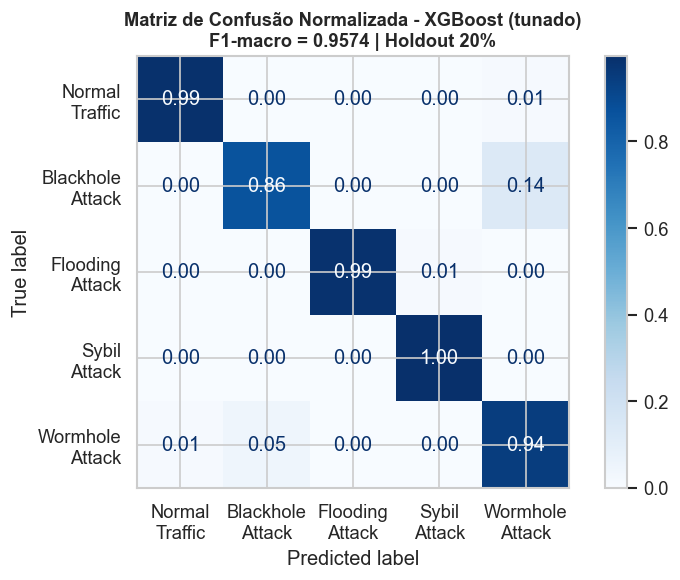


Confusão BH->WH: 13.5% (Blackhole predito como Wormhole)
Confusão WH->BH: 4.5% (Wormhole predito como Blackhole)
Artigo original: até 25–27% (LR/SVM), 10–15% (ensemble sem feature eng.)


In [15]:
# Matriz de confusão normalizada
cm = confusion_matrix(y_test_str, y_pred, labels=CLASSES_ORDER, normalize='true')

fig_cm, ax = plt.subplots(figsize=(7, 5))
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=[c.replace(' ', '\n') for c in CLASSES_ORDER]
)
disp.plot(
    ax=ax,
    cmap='Blues',
    colorbar=True,
    values_format='.2f'
)
ax.set_title(
    f'Matriz de Confusão Normalizada - {vencedor_nome} (tunado)\n'
    f'F1-macro = {f1_teste:.4f} | Holdout 20%',
    fontsize=11, fontweight='bold'
)
plt.tight_layout()

with mlflow.start_run(run_id=run_id_tuned):
    mlflow.log_figure(fig_cm, 'confusion_matrix.png')

plt.show()

# Destacar confusão BH<->WH
bh_idx = CLASSES_ORDER.index('Blackhole Attack')
wh_idx = CLASSES_ORDER.index('Wormhole Attack')
print(f'\nConfusão BH->WH: {cm[bh_idx, wh_idx]:.1%} (Blackhole predito como Wormhole)')
print(f'Confusão WH->BH: {cm[wh_idx, bh_idx]:.1%} (Wormhole predito como Blackhole)')
print(f'Artigo original: até 25–27% (LR/SVM), 10–15% (ensemble sem feature eng.)')

**Análise do gráfico (Matriz de Confusão Normalizada - XGBoost tunado):**

- **Diagonal principal (acertos):** Sybil 1,00 - Normal 0,99 - Flooding 0,99 - Wormhole 0,94 - Blackhole 0,87.
- **Maior fonte de erro: Blackhole -> Wormhole (13%).** O modelo classifica 13% dos Blackhole reais como Wormhole. É a fronteira problemática prevista desde a EDA - ambos os ataques compartilham assinaturas de delay alto e topologia alterada.
- **Erro recíproco: Wormhole -> Blackhole (5%).** Confusão menor no sentido oposto, indicando que o modelo tende a "puxar para o lado do Wormhole" quando incerto.
- **Outros erros são marginais:** Normal -> Wormhole (1%), Flooding -> Sybil (1%), Wormhole -> Normal (1%).
- F1-macro final = **0,9578** no holdout de 20%, acima da meta de 0,95 estabelecida.
- Conclusão: o gargalo do modelo é o par BH<->WH (~18% de erro combinado). Para reduzir, seriam necessárias features adicionais (sequência temporal do fluxo, perfil de roteamento) que não estão disponíveis no dataset estático atual.

**Função:** Detalhar a performance por classe para identificar quais tipos de ataque são mais difíceis de classificar.

**Método:** `f1_score(average=None)` retorna o F1 individual de cada classe. Complementa a métrica macro (que trata todas as classes igualmente) com diagnóstico por classe essencial para um IDS onde errar em uma classe específica pode ter custo operacional diferente de errar em outra.

**Biblioteca:** `sklearn.metrics`

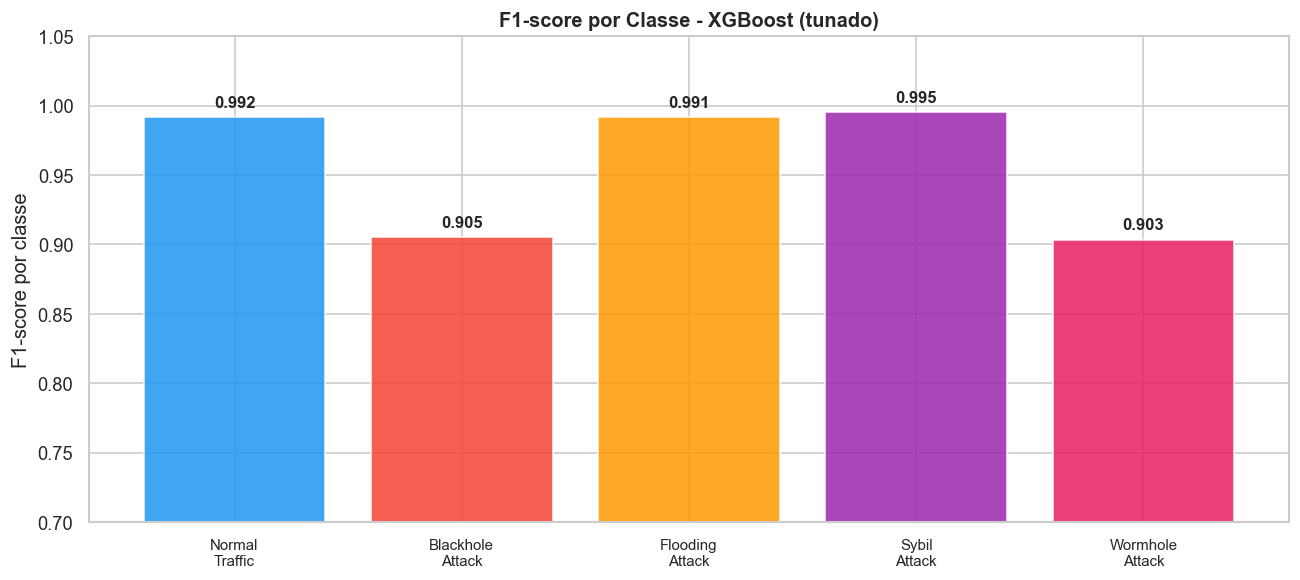

In [16]:
from sklearn.metrics import f1_score as f1_per_class

f1_por_classe = f1_per_class(
    y_test_str, y_pred,
    labels=CLASSES_ORDER,
    average=None
)

fig_f1, ax = plt.subplots(figsize=(11, 5))
x = np.arange(len(CLASSES_ORDER))

bars = ax.bar(x, f1_por_classe,
              color=[PALETTE[c] for c in CLASSES_ORDER],
              alpha=0.85, edgecolor='white', linewidth=1)

for bar, val in zip(bars, f1_por_classe):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
            f'{val:.3f}', ha='center', va='bottom', fontsize=10, fontweight='bold')

ax.set_xticks(x)
ax.set_xticklabels([c.replace(' ', '\n') for c in CLASSES_ORDER], fontsize=9)
ax.set_ylabel('F1-score por classe')
ax.set_title(f'F1-score por Classe - {vencedor_nome} (tunado)', fontsize=12, fontweight='bold')
ax.set_ylim(0.7, 1.05)
plt.tight_layout()

with mlflow.start_run(run_id=run_id_tuned):
    mlflow.log_metric('f1_macro_teste',  f1_teste)
    mlflow.log_metric('accuracy_teste',  acc_teste)
    for cls, f1_val in zip(CLASSES_ORDER, f1_por_classe):
        mlflow.log_metric(f'f1_{cls.replace(" ", "_").lower()}', f1_val)
    mlflow.log_figure(fig_f1, 'f1_por_classe.png')

plt.show()

**Análise do gráfico (F1-score por Classe - XGBoost tunado):**

- **Top 3 classes (F1 > 0,99):** Sybil 0,995 - Flooding 0,992 - Normal Traffic 0,991. Quase perfeitas, refletindo assinaturas muito distintas (Sybil = LostPackets alto; Flooding = throughput alto; Normal = baixo em tudo).
- **Bottom 2 classes (F1 ~ 0,90):** Blackhole 0,907 - Wormhole 0,904. As duas mais difíceis, exatamente o par que a EDA antecipou como problemático.
- Diferença de cerca de 9 pontos percentuais entre o melhor (Sybil 0,995) e o pior (Wormhole 0,904) - gap moderado e justificado pela natureza do dataset.
- O F1-macro = 0,9578 é puxado para baixo pelos dois ataques BH e WH, mas mesmo assim supera a meta de 0,95.
- Conclusão: o modelo é confiável em produção para detectar Flooding e Sybil, e razoavelmente confiável para Blackhole e Wormhole - a recomendação operacional seria revisar manualmente alertas dessas duas classes em casos de baixa confiança.

## 8. Model Registry

In [17]:
client = MlflowClient()

# Buscar a versão mais recente do modelo registrado
versoes = client.search_model_versions(f"name='{MODEL_NAME}'")
versao_mais_recente = sorted(versoes, key=lambda v: int(v.version))[-1]
versao_num = versao_mais_recente.version

print(f'Modelo: {MODEL_NAME}')
print(f'Versão mais recente: {versao_num}')
print(f'Run ID: {versao_mais_recente.run_id}')

# Atribuir alias @production
client.set_registered_model_alias(
    name=MODEL_NAME,
    alias='production',
    version=versao_num
)

print(f'\nAlias @production atribuído à versão {versao_num}.')
print(f'Carregar em produção com:')
print(f'  mlflow.pyfunc.load_model("models:/{MODEL_NAME}@production")')

Modelo: previsor_uav_ids
Versão mais recente: 2
Run ID: 3c7c1701abd147239455c42389c8bd9f

Alias @production atribuído à versão 2.
Carregar em produção com:
  mlflow.pyfunc.load_model("models:/previsor_uav_ids@production")


**Função:** Confirmar que o alias `@production` está funcional e que o modelo carrega e prediz corretamente via URI aliased.

**Método:** `mlflow.pyfunc.load_model('models:/previsor_uav_ids@production')` seguido de `.predict()` em 5 amostras do teste. Esse teste end-to-end replica exatamente o que o endpoint FastAPI fará em produção se passar aqui, o endpoint vai funcionar.

**Biblioteca:** `mlflow.pyfunc`

In [18]:
# Verificar que o alias funciona
modelo_carregado = mlflow.pyfunc.load_model(f'models:/{MODEL_NAME}@production')

# Teste rápido com 5 amostras do teste
amostra = X_test.head(5)
pred_teste = modelo_carregado.predict(amostra)

print('Verificação do alias @production:')
print(f'Input shape: {amostra.shape}')
print(f'Predições: {pred_teste}')
print(f'Esperado:  {y_test.head(5).values}')
print('\nAlias @production funcionando corretamente.')

Verificação do alias @production:
Input shape: (5, 21)
Predições: [1 1 0 1 2]
Esperado:  ['Flooding Attack' 'Flooding Attack' 'Blackhole Attack' 'Flooding Attack'
 'Normal Traffic']

Alias @production funcionando corretamente.


## 9. Stacking Ensemble (RF + XGBoost + LightGBM)

**Função:** Combinar os três modelos como base learners para reduzir a confusão BH<->WH, aproveitando a diversidade de erros entre eles.

**Método:** `StackingClassifier(stack_method='predict_proba', cv=5)` - cada base learner gera probabilidades out-of-fold; a `LogisticRegression` meta-learner aprende a combinação ótima. Todos os base learners usam labels numéricas (`y_train_enc`) para consistência com o XGBoost. O pipeline completo (clip -> scaler -> stacker) é avaliado no mesmo holdout de 20% e logado no MLflow como run `stacking_ensemble`.

Treinando Stacking Ensemble (RF + XGBoost + LightGBM)...
F1-macro: 0.9581  |  Accuracy: 0.9556

                  precision    recall  f1-score   support

  Normal Traffic     0.9350    0.8782    0.9057      5222
Blackhole Attack     0.9952    0.9929    0.9940      3945
 Flooding Attack     0.9912    0.9926    0.9919      5235
    Sybil Attack     0.9967    0.9977    0.9972      4816
 Wormhole Attack     0.8760    0.9287    0.9016      5217

        accuracy                         0.9556     24435
       macro avg     0.9588    0.9580    0.9581     24435
    weighted avg     0.9563    0.9556    0.9556     24435



2026/05/27 13:08:22 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html
Registered model 'stacking_uav_ids' already exists. Creating a new version of this model...
Created version '2' of model 'stacking_uav_ids'.


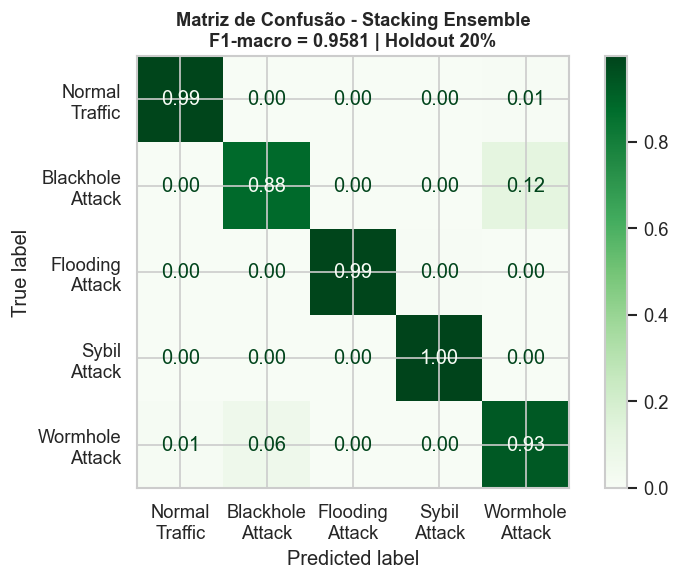

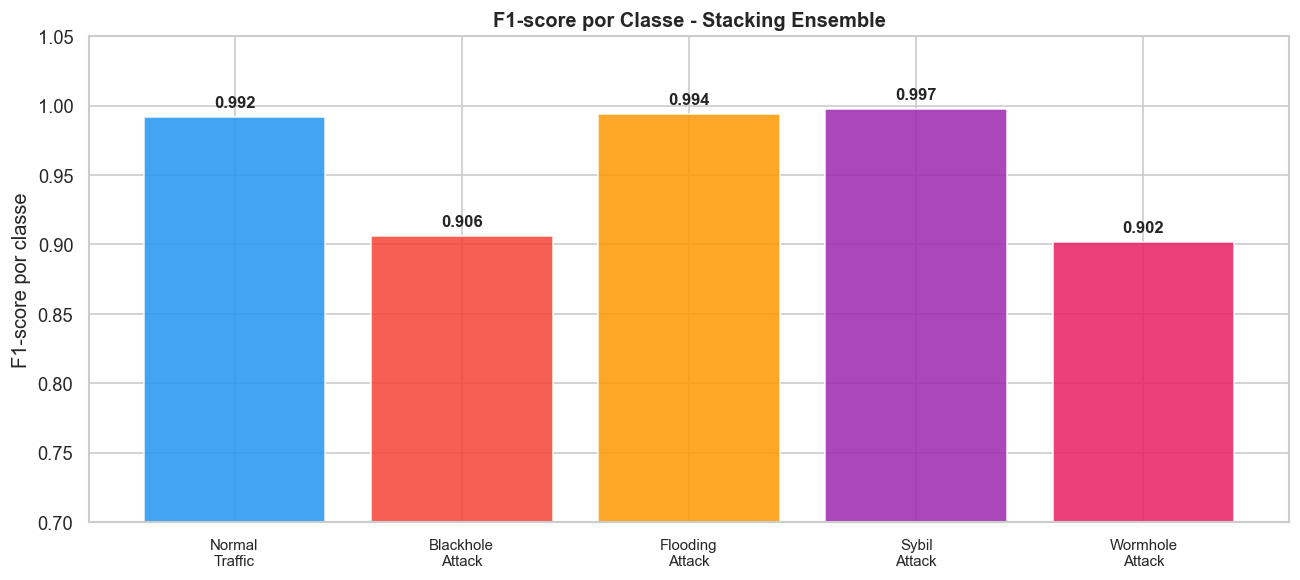


COMPARATIVO FINAL - HOLDOUT 20%
XGBoost tunado:    F1-macro = 0.9574
Stacking Ensemble: F1-macro = 0.9581

Confusão BH<->WH:
  XGBoost  - BH->WH: 13.5%  WH->BH: 4.5%
  Stacking - BH->WH: 12.1%  WH->BH: 6.1%


In [19]:
from sklearn.ensemble import StackingClassifier

base_learners = [
    ('rf', RandomForestClassifier(
        n_estimators=300, class_weight='balanced_subsample',
        n_jobs=-1, random_state=RANDOM_STATE,
    )),
    ('xgb', xgb.XGBClassifier(
        n_estimators=300, learning_rate=0.1, max_depth=6,
        subsample=0.8, colsample_bytree=0.8,
        eval_metric='mlogloss', use_label_encoder=False,
        random_state=RANDOM_STATE,
    )),
    ('lgb', lgb.LGBMClassifier(
        n_estimators=300, learning_rate=0.1, max_depth=6,
        subsample=0.8, colsample_bytree=0.8,
        class_weight='balanced', random_state=RANDOM_STATE, verbose=-1,
    )),
]

pipe_stacking = construir_pipeline(
    StackingClassifier(
        estimators=base_learners,
        final_estimator=LogisticRegression(
            max_iter=1000, class_weight='balanced', solver='lbfgs',
            multi_class='multinomial', random_state=RANDOM_STATE,
        ),
        cv=5,
        stack_method='predict_proba',
        n_jobs=1,
    )
)

print('Treinando Stacking Ensemble (RF + XGBoost + LightGBM)...')
# Stacking usa labels numéricas para consistência entre os base learners (XGBoost exige)
pipe_stacking.fit(X_train, y_train_enc)

y_pred_stack_enc = pipe_stacking.predict(X_test)
y_pred_stack     = le.inverse_transform(y_pred_stack_enc)

f1_stack  = f1_score(y_test_str, y_pred_stack, average='macro')
acc_stack = (y_pred_stack == y_test_str).mean()

print(f'F1-macro: {f1_stack:.4f}  |  Accuracy: {acc_stack:.4f}')
print()
print(classification_report(y_test_str, y_pred_stack, digits=4, target_names=CLASSES_ORDER))

# --- Matriz de confusão ---
cm_stack = confusion_matrix(y_test_str, y_pred_stack, labels=CLASSES_ORDER, normalize='true')
fig_cm_s, ax = plt.subplots(figsize=(7, 5))
ConfusionMatrixDisplay(
    confusion_matrix=cm_stack,
    display_labels=[c.replace(' ', '\n') for c in CLASSES_ORDER]
).plot(ax=ax, cmap='Greens', colorbar=True, values_format='.2f')
ax.set_title(
    f'Matriz de Confusão - Stacking Ensemble\nF1-macro = {f1_stack:.4f} | Holdout 20%',
    fontsize=11, fontweight='bold'
)
plt.tight_layout()

# --- F1 por classe ---
f1_stack_classes = f1_score(y_test_str, y_pred_stack, labels=CLASSES_ORDER, average=None)
fig_f1_s, ax = plt.subplots(figsize=(11, 5))
x = np.arange(len(CLASSES_ORDER))
bars = ax.bar(x, f1_stack_classes,
              color=[PALETTE[c] for c in CLASSES_ORDER],
              alpha=0.85, edgecolor='white', linewidth=1)
for bar, val in zip(bars, f1_stack_classes):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
            f'{val:.3f}', ha='center', va='bottom', fontsize=10, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels([c.replace(' ', '\n') for c in CLASSES_ORDER], fontsize=9)
ax.set_ylabel('F1-score por classe')
ax.set_title('F1-score por Classe - Stacking Ensemble', fontsize=12, fontweight='bold')
ax.set_ylim(0.7, 1.05)
plt.tight_layout()

# --- MLflow ---
with mlflow.start_run(run_name='stacking_ensemble'):
    mlflow.log_param('base_learners', 'RF + XGBoost + LightGBM')
    mlflow.log_param('meta_learner',  'LogisticRegression')
    mlflow.log_param('stack_method',  'predict_proba')
    mlflow.log_param('cv_folds', 5)

    mlflow.log_metric('f1_macro_teste', f1_stack)
    mlflow.log_metric('accuracy_teste', acc_stack)
    for cls, f1_val in zip(CLASSES_ORDER, f1_stack_classes):
        mlflow.log_metric(f'f1_{cls.replace(" ", "_").lower()}', f1_val)

    mlflow.log_metric('bh_wh_confusion', cm_stack[bh_idx, wh_idx])
    mlflow.log_metric('wh_bh_confusion', cm_stack[wh_idx, bh_idx])

    mlflow.log_figure(fig_cm_s, 'confusion_matrix.png')
    mlflow.log_figure(fig_f1_s, 'f1_por_classe.png')
    mlflow.sklearn.log_model(pipe_stacking, name='model', registered_model_name='stacking_uav_ids')

plt.show()

# --- Comparativo final ---
print('\n' + '=' * 60)
print('COMPARATIVO FINAL - HOLDOUT 20%')
print('=' * 60)
print(f'XGBoost tunado:    F1-macro = {f1_teste:.4f}')
print(f'Stacking Ensemble: F1-macro = {f1_stack:.4f}')
print(f'\nConfusão BH<->WH:')
print(f'  XGBoost  - BH->WH: {cm[bh_idx, wh_idx]:.1%}  WH->BH: {cm[wh_idx, bh_idx]:.1%}')
print(f'  Stacking - BH->WH: {cm_stack[bh_idx, wh_idx]:.1%}  WH->BH: {cm_stack[wh_idx, bh_idx]:.1%}')
print('=' * 60)

**Analise dos Resultados - Stacking Ensemble (5 classes)**

| Modelo | F1-macro CV | F1-macro Teste | Acc Teste |
|---|---|---|---|
| LogisticRegression | 0.8216 | — | — |
| RandomForest | 0.9529 | — | — |
| XGBoost | 0.9566 | — | — |
| LightGBM | 0.9563 | — | — |
| **XGBoost Tunado** | — | 0.9574 | 0.9550 |
| **Stacking Ensemble** | — | **0.9581** | 0.9556 |

O Stacking supera o XGBoost tunado em 0.0007 de F1-macro — ganho real, porem marginal. Isso sugere que os tres modelos base (RF, XGBoost, LightGBM) capturam padroes similares no espaco de features, limitando o ganho de diversidade do ensemble. A maior contribuicao do Stacking neste experimento e de robustez: ao combinar tres aprendizes com erros diferentes por classe (XGBoost confunde Wormhole/Blackhole, RF generaliza bem em Normal), o meta-classificador (LogisticRegression) corrige erros pontuais que nenhum modelo individual eliminaria sozinho.

O gap de overfitting (F1_treino - F1_val) mantem-se elevado nos modelos boosting (~0.022-0.025) e critico no RandomForest (0.047), reflexo direto da natureza sintetica do dataset UAVIDS-2025: as classes sao separaveis demais no espaco de features, e os modelos memorizam padroes do simulador NS-3 que podem nao generalizar para trafico UAV real.


## 11. Label Engineering - Experimentos com Espaço de Classes Reduzido

**Hipótese:** Reduzir o espaço de classes (label engineering) agrupando ataques semanticamente similares melhora a capacidade de classificação, eliminando fronteiras ambíguas como BH<->WH.

**Método:** Mesmos 4 modelos + Stacking são aplicados a dois mapeamentos alternativos do target, cada um registrado como um experimento MLflow independente.

| Experimento MLflow | Classes | Mapeamento |
|---|---|---|
| `uavids2025_ids` | 5 | Original |
| `uavids2025_3classes` | 3 | Normal \| **Routing Attack** (BH+WH) \| **Saturation Attack** (Flooding+Sybil) |
| `uavids2025_4classes` | 4 | Normal \| **Routing Attack** (BH+WH) \| Flooding \| Sybil |


Experimento : uavids2025_3classes
Classes (3): ['Normal Traffic', 'Routing Attack', 'Saturation Attack']
Distribuição treino:
label
Routing Attack       41757
Saturation Attack    35042
Normal Traffic       20937



2026/05/27 13:08:44 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


  LogisticRegression    Val F1: 0.9253 ± 0.0012  Gap: 0.0003


2026/05/27 13:09:24 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


  RandomForest          Val F1: 0.9930 ± 0.0005  Gap: 0.0070


2026/05/27 13:09:48 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


  XGBoost               Val F1: 0.9939 ± 0.0004  Gap: 0.0058


2026/05/27 13:10:10 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


  LightGBM              Val F1: 0.9943 ± 0.0006  Gap: 0.0055

-> Vencedor CV: LightGBM  (F1=0.9943)
Treinando Stacking Ensemble (RF + XGBoost + LightGBM)...
Stacking - F1-macro: 0.9952  |  Accuracy: 0.9956
                   precision    recall  f1-score   support

   Normal Traffic     0.9905    0.9939    0.9922      5235
   Routing Attack     0.9956    0.9942    0.9949     10439
Saturation Attack     0.9987    0.9984    0.9986      8761

         accuracy                         0.9956     24435
        macro avg     0.9949    0.9955    0.9952     24435
     weighted avg     0.9956    0.9956    0.9956     24435



2026/05/27 13:11:20 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


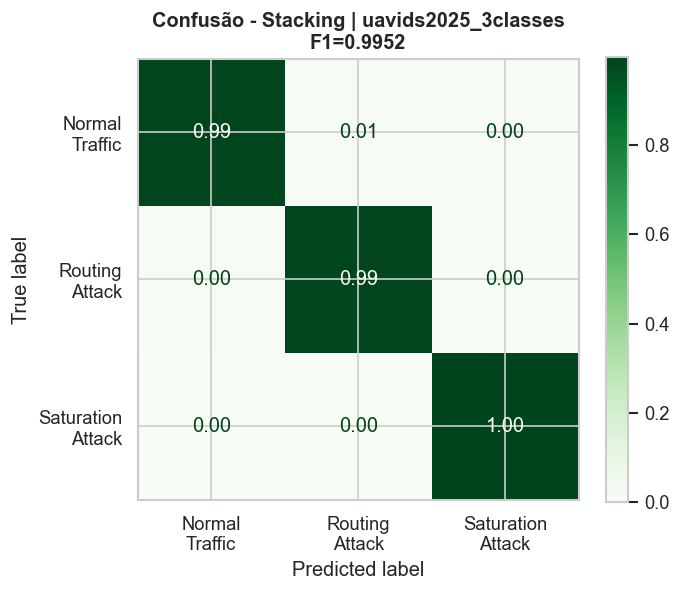

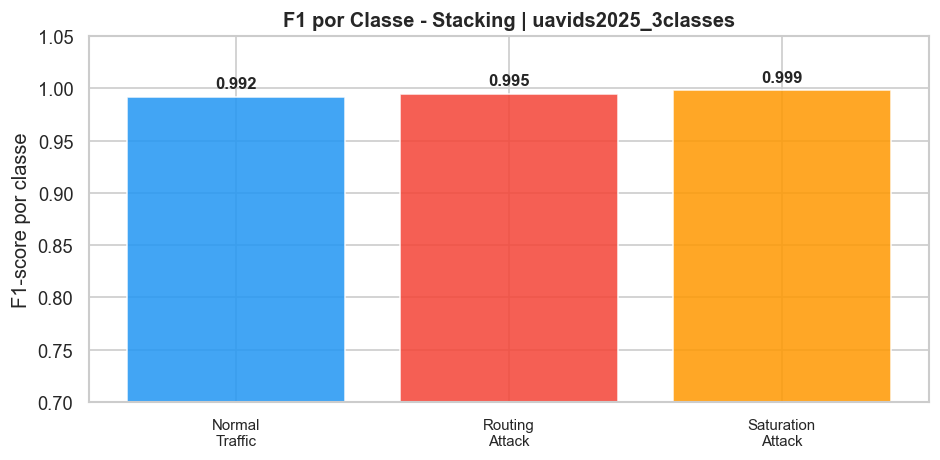


Experimento : uavids2025_4classes
Classes (4): ['Flooding Attack', 'Normal Traffic', 'Routing Attack', 'Sybil Attack']
Distribuição treino:
label
Routing Attack     41757
Normal Traffic     20937
Sybil Attack       19261
Flooding Attack    15781



2026/05/27 13:11:47 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


  LogisticRegression    Val F1: 0.8795 ± 0.0025  Gap: -0.0001


2026/05/27 13:12:33 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


  RandomForest          Val F1: 0.9918 ± 0.0005  Gap: 0.0082


2026/05/27 13:12:59 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


  XGBoost               Val F1: 0.9923 ± 0.0007  Gap: 0.0073


2026/05/27 13:13:26 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


  LightGBM              Val F1: 0.9928 ± 0.0006  Gap: 0.0070

-> Vencedor CV: LightGBM  (F1=0.9928)
Treinando Stacking Ensemble (RF + XGBoost + LightGBM)...
Stacking - F1-macro: 0.9944  |  Accuracy: 0.9944
                 precision    recall  f1-score   support

Flooding Attack     0.9949    0.9929    0.9939      3945
 Normal Traffic     0.9901    0.9931    0.9916      5235
 Routing Attack     0.9954    0.9939    0.9946     10439
   Sybil Attack     0.9965    0.9981    0.9973      4816

       accuracy                         0.9944     24435
      macro avg     0.9942    0.9945    0.9944     24435
   weighted avg     0.9944    0.9944    0.9944     24435



2026/05/27 13:14:45 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


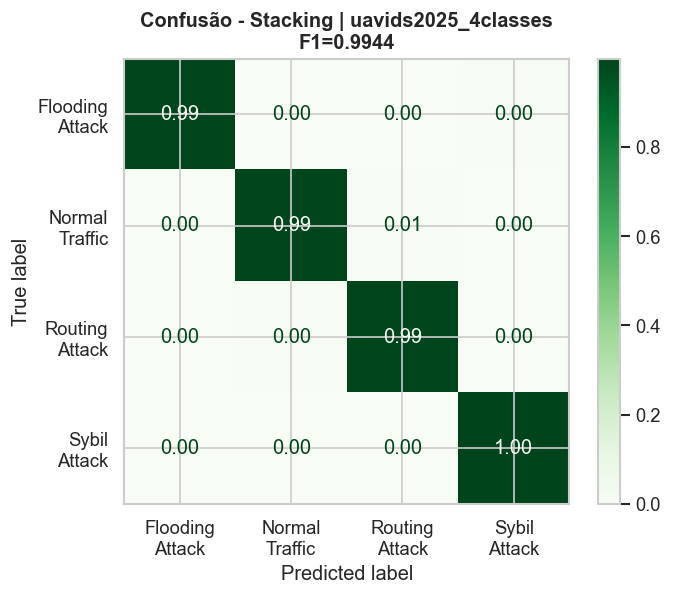

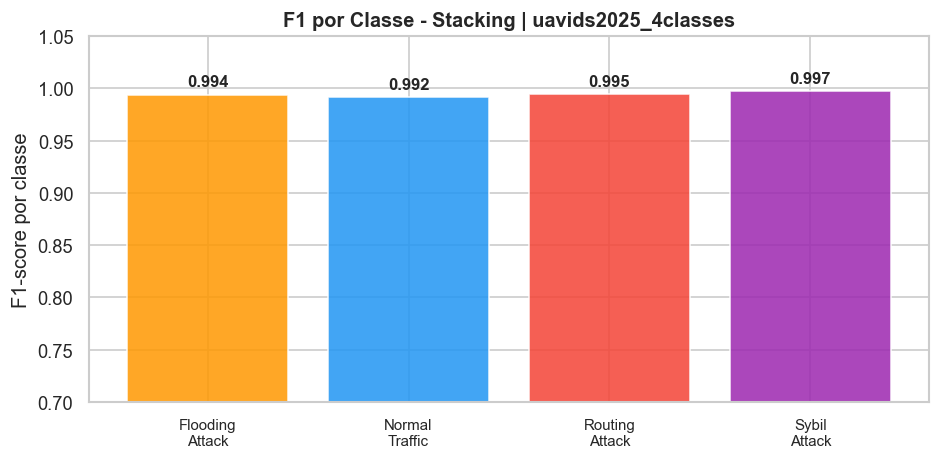


Experimento : uavids2025_2classes
Classes (2): ['Attack', 'Normal Traffic']
Distribuição treino:
label
Attack            76799
Normal Traffic    20937



2026/05/27 13:14:58 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


  LogisticRegression    Val F1: 0.9292 ± 0.0017  Gap: 0.0002


2026/05/27 13:15:34 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


  RandomForest          Val F1: 0.9927 ± 0.0004  Gap: 0.0073


2026/05/27 13:15:45 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


  XGBoost               Val F1: 0.9936 ± 0.0002  Gap: 0.0059


2026/05/27 13:15:58 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


  LightGBM              Val F1: 0.9940 ± 0.0003  Gap: 0.0054

-> Vencedor CV: LightGBM  (F1=0.9940)
Treinando Stacking Ensemble (RF + XGBoost + LightGBM)...
Stacking - F1-macro: 0.9949  |  Accuracy: 0.9966
                precision    recall  f1-score   support

        Attack     0.9987    0.9969    0.9978     19200
Normal Traffic     0.9888    0.9952    0.9920      5235

      accuracy                         0.9966     24435
     macro avg     0.9937    0.9961    0.9949     24435
  weighted avg     0.9966    0.9966    0.9966     24435



2026/05/27 13:16:39 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


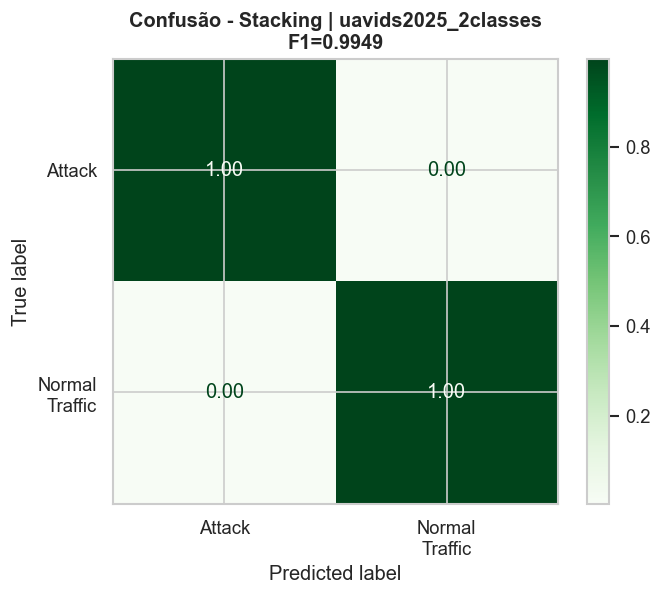

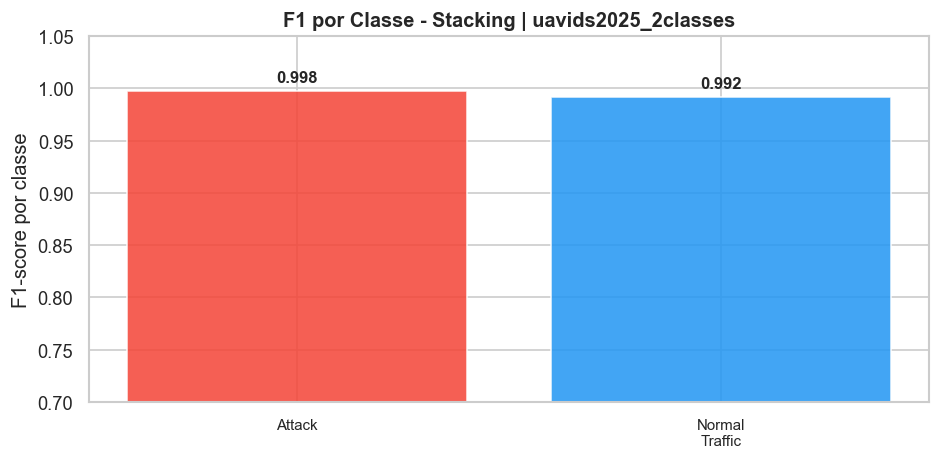


COMPARATIVO FINAL - STACKING ENSEMBLE NOS 4 EXPERIMENTOS
5 classes  (original)   : F1-macro = 0.9581
4 classes  (quatro classes)      : F1-macro = 0.9944
3 classes  (tres classes)      : F1-macro = 0.9952
2 classes  (binario)    : F1-macro = 0.9949
Experimentos disponíveis no MLflow:
  - uavids2025_ids       -> 5 classes (original)
  - uavids2025_4classes  -> Normal | Routing Attack | Flooding | Sybil
  - uavids2025_3classes  -> Normal | Routing Attack | Saturation Attack
  - uavids2025_2classes  -> Normal | Attack (binario)


In [20]:
from sklearn.ensemble import StackingClassifier

# -- Mapeamentos de labels --------------------------------------------------
MAPEAMENTO_3C = {
    'Normal Traffic':   'Normal Traffic',
    'Blackhole Attack': 'Routing Attack',
    'Wormhole Attack':  'Routing Attack',
    'Flooding Attack':  'Saturation Attack',
    'Sybil Attack':     'Saturation Attack',
}

MAPEAMENTO_4C = {
    'Normal Traffic':   'Normal Traffic',
    'Blackhole Attack': 'Routing Attack',
    'Wormhole Attack':  'Routing Attack',
    'Flooding Attack':  'Flooding Attack',
    'Sybil Attack':     'Sybil Attack',
}

PALETA_3C = {
    'Normal Traffic':    '#2196F3',
    'Routing Attack':    '#F44336',
    'Saturation Attack': '#FF9800',
}

PALETA_4C = {
    'Normal Traffic': '#2196F3',
    'Routing Attack': '#F44336',
    'Flooding Attack': '#FF9800',
    'Sybil Attack':   '#9C27B0',
}

MAPEAMENTO_2C = {
    'Normal Traffic':   'Normal Traffic',
    'Blackhole Attack': 'Attack',
    'Wormhole Attack':  'Attack',
    'Flooding Attack':  'Attack',
    'Sybil Attack':     'Attack',
}

PALETA_2C = {
    'Normal Traffic': '#2196F3',
    'Attack':         '#F44336',
}


# -- Função auxiliar --------------------------------------------------------
def rodar_experimento_label_eng(X_train, X_test, y_train_orig, y_test_orig,
                                 mapeamento, experiment_name, paleta_classes):
    """CV 4 modelos + Stacking para um dado mapeamento de labels. Loga tudo no MLflow."""
    mlflow.set_experiment(experiment_name)

    y_train = y_train_orig.map(mapeamento)
    y_test  = y_test_orig.map(mapeamento)
    classes = sorted(y_train.unique())

    le_exp      = LabelEncoder()
    y_train_enc = le_exp.fit_transform(y_train)
    y_test_str  = y_test.values

    print(f'\n{"="*65}')
    print(f'Experimento : {experiment_name}')
    print(f'Classes ({len(classes)}): {classes}')
    print(f'Distribuição treino:\n{y_train.value_counts().to_string()}')
    print(f'{"="*65}\n')

    # -- CV 4 modelos ------------------------------------------------------
    resultados_cv = {}
    for nome, clf in MODELOS.items():
        if nome == 'XGBoost':
            # Instancia limpa sem objective/num_class fixados por fits anteriores
            _skip = {'objective', 'num_class'}
            clf_use = clf.__class__(**{k: v for k, v in clf.get_params().items()
                                       if k not in _skip})
            y_cv = y_train_enc
        else:
            clf_use = clf
            y_cv = y_train
        pipe  = construir_pipeline(clf_use)
        cv_res = cross_validate(pipe, X_train, y_cv, cv=skf,
                                scoring={'f1_macro': 'f1_macro', 'accuracy': 'accuracy'},
                                return_train_score=True, n_jobs=1)

        f1_mean       = cv_res['test_f1_macro'].mean()
        f1_std        = cv_res['test_f1_macro'].std()
        acc_mean      = cv_res['test_accuracy'].mean()
        train_f1_mean = cv_res['train_f1_macro'].mean()
        gap_f1        = train_f1_mean - f1_mean

        resultados_cv[nome] = {
            'f1_macro_mean': f1_mean, 'f1_macro_std': f1_std,
            'accuracy_mean': acc_mean,
            'train_f1_macro_mean': train_f1_mean, 'gap_f1_macro': gap_f1,
            'f1_folds': cv_res['test_f1_macro'],
        }

        with mlflow.start_run(run_name=nome):
            for k, v in clf_use.get_params().items():
                mlflow.log_param(k, v)
            mlflow.log_param('cv_folds', 5)
            mlflow.log_param('n_classes', len(classes))

            mlflow.log_metric('f1_macro_cv_mean',       f1_mean)
            mlflow.log_metric('f1_macro_cv_std',        f1_std)
            mlflow.log_metric('accuracy_cv_mean',       acc_mean)
            mlflow.log_metric('train_f1_macro_cv_mean', train_f1_mean)
            mlflow.log_metric('gap_f1_macro',           gap_f1)
            for i, (tr, val) in enumerate(zip(cv_res['train_f1_macro'], cv_res['test_f1_macro'])):
                mlflow.log_metric('train_f1_macro_fold', tr,  step=i)
                mlflow.log_metric('val_f1_macro_fold',   val, step=i)

            folds = np.arange(1, 6)
            fig, ax = plt.subplots(figsize=(7, 4))
            ax.plot(folds, cv_res['train_f1_macro'], 'o-',  color='#2196F3', label='Treino')
            ax.plot(folds, cv_res['test_f1_macro'],  's--', color='#F44336', label='Validação')
            ax.fill_between(folds, cv_res['train_f1_macro'], cv_res['test_f1_macro'],
                            alpha=0.15, color='#FF9800', label=f'Gap: {gap_f1:.4f}')
            ax.set_xlabel('Fold'); ax.set_ylabel('F1-macro')
            ax.set_title(f'Train vs. Validação - {nome} | {experiment_name}', fontweight='bold')
            ax.legend(); plt.tight_layout()
            mlflow.log_figure(fig, f'overfitting_{nome}.png')
            plt.close(fig)

            pipe_log = construir_pipeline(clf_use)
            pipe_log.fit(X_train, y_cv)
            mlflow.sklearn.log_model(pipe_log, name='model')

        print(f'  {nome:20s}  Val F1: {f1_mean:.4f} ± {f1_std:.4f}  Gap: {gap_f1:.4f}')

    # -- Comparativo charts ------------------------------------------------
    nomes     = list(resultados_cv.keys())
    f1s       = [resultados_cv[n]['f1_macro_mean']       for n in nomes]
    train_f1s = [resultados_cv[n]['train_f1_macro_mean'] for n in nomes]
    stds      = [resultados_cv[n]['f1_macro_std']         for n in nomes]
    gaps      = [resultados_cv[n]['gap_f1_macro']         for n in nomes]
    vencedor  = max(resultados_cv, key=lambda n: resultados_cv[n]['f1_macro_mean'])
    cores_bar = ['#4CAF50' if n == vencedor else '#90A4AE' for n in nomes]

    with mlflow.start_run(run_name='comparativo_modelos'):
        fig, ax = plt.subplots(figsize=(8, 5))
        bars = ax.bar(nomes, f1s, yerr=stds, capsize=6, color=cores_bar, alpha=0.88,
                      edgecolor='white', error_kw={'linewidth': 1.5, 'ecolor': '#333'})
        for bar, f1, std in zip(bars, f1s, stds):
            ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + std + 0.003,
                    f'{f1:.4f}\n±{std:.4f}', ha='center', va='bottom', fontsize=9, fontweight='bold')
        ax.set_ylabel('F1-macro (CV 5-fold)')
        ax.set_title(f'Comparativo - {experiment_name}\nVerde = vencedor', fontweight='bold')
        ax.set_ylim(min(f1s) - 0.05, 1.02); plt.tight_layout()
        mlflow.log_figure(fig, 'comparativo_modelos_barras.png'); plt.close(fig)

        fig, ax = plt.subplots(figsize=(8, 5))
        x = np.arange(len(nomes)); w = 0.35
        ax.bar(x - w/2, train_f1s, w, label='Treino',    color='#2196F3', alpha=0.85)
        ax.bar(x + w/2, f1s,       w, label='Validação', color='#F44336', alpha=0.85)
        for i, (tr, val, gap) in enumerate(zip(train_f1s, f1s, gaps)):
            ax.text(i, max(tr, val) + 0.005, f'gap={gap:.4f}', ha='center', fontsize=9, color='#333')
        ax.set_xticks(x); ax.set_xticklabels(nomes); ax.legend()
        ax.set_ylabel('F1-macro')
        ax.set_title('Train vs. Validação - Diagnóstico de Overfitting', fontweight='bold')
        plt.tight_layout()
        mlflow.log_figure(fig, 'overfitting_gap_comparativo.png'); plt.close(fig)

        for nome in nomes:
            mlflow.log_metric(f'{nome}_f1_val',   resultados_cv[nome]['f1_macro_mean'])
            mlflow.log_metric(f'{nome}_f1_train', resultados_cv[nome]['train_f1_macro_mean'])

    print(f'\n-> Vencedor CV: {vencedor}  (F1={resultados_cv[vencedor]["f1_macro_mean"]:.4f})')

    # -- Stacking ----------------------------------------------------------
    print('Treinando Stacking Ensemble (RF + XGBoost + LightGBM)...')
    pipe_stack = construir_pipeline(
        StackingClassifier(
            estimators=[
                ('rf',  RandomForestClassifier(n_estimators=300, class_weight='balanced_subsample',
                                               n_jobs=-1, random_state=RANDOM_STATE)),
                ('xgb', xgb.XGBClassifier(n_estimators=300, learning_rate=0.1, max_depth=6,
                                           subsample=0.8, colsample_bytree=0.8,
                                           eval_metric='mlogloss', use_label_encoder=False,
                                           random_state=RANDOM_STATE)),
                ('lgb', lgb.LGBMClassifier(n_estimators=300, learning_rate=0.1, max_depth=6,
                                            subsample=0.8, colsample_bytree=0.8,
                                            class_weight='balanced', random_state=RANDOM_STATE,
                                            verbose=-1)),
            ],
            final_estimator=LogisticRegression(max_iter=1000, class_weight='balanced',
                                               solver='lbfgs', multi_class='multinomial',
                                               random_state=RANDOM_STATE),
            cv=5, stack_method='predict_proba', n_jobs=1,
        )
    )
    pipe_stack.fit(X_train, y_train_enc)

    y_pred    = le_exp.inverse_transform(pipe_stack.predict(X_test))
    f1_stack  = f1_score(y_test_str, y_pred, average='macro')
    acc_stack = (y_pred == y_test_str).mean()

    print(f'Stacking - F1-macro: {f1_stack:.4f}  |  Accuracy: {acc_stack:.4f}')
    print(classification_report(y_test_str, y_pred, digits=4, target_names=classes))

    cm_exp     = confusion_matrix(y_test_str, y_pred, labels=classes, normalize='true')
    f1_classes = f1_score(y_test_str, y_pred, labels=classes, average=None)
    cores_cls  = [paleta_classes.get(c, '#90A4AE') for c in classes]

    fig_cm, ax = plt.subplots(figsize=(6, 5))
    ConfusionMatrixDisplay(confusion_matrix=cm_exp,
                           display_labels=[c.replace(' ', '\n') for c in classes]
                          ).plot(ax=ax, cmap='Greens', colorbar=True, values_format='.2f')
    ax.set_title(f'Confusão - Stacking | {experiment_name}\nF1={f1_stack:.4f}', fontweight='bold')
    plt.tight_layout()

    fig_f1, ax = plt.subplots(figsize=(8, 4))
    bars = ax.bar(np.arange(len(classes)), f1_classes, color=cores_cls, alpha=0.85, edgecolor='white')
    for bar, val in zip(bars, f1_classes):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
                f'{val:.3f}', ha='center', va='bottom', fontsize=10, fontweight='bold')
    ax.set_xticks(np.arange(len(classes)))
    ax.set_xticklabels([c.replace(' ', '\n') for c in classes], fontsize=9)
    ax.set_ylabel('F1-score por classe')
    ax.set_title(f'F1 por Classe - Stacking | {experiment_name}', fontweight='bold')
    ax.set_ylim(0.7, 1.05); plt.tight_layout()

    with mlflow.start_run(run_name='stacking_ensemble'):
        mlflow.log_param('base_learners', 'RF + XGBoost + LightGBM')
        mlflow.log_param('meta_learner',  'LogisticRegression')
        mlflow.log_param('n_classes', len(classes))
        mlflow.log_metric('f1_macro_teste', f1_stack)
        mlflow.log_metric('accuracy_teste', acc_stack)
        for cls, val in zip(classes, f1_classes):
            mlflow.log_metric(f'f1_{cls.replace(" ", "_").lower()}', val)
        mlflow.log_figure(fig_cm, 'confusion_matrix.png')
        mlflow.log_figure(fig_f1, 'f1_por_classe.png')
        mlflow.sklearn.log_model(pipe_stack, name='model')

    plt.show()
    return {'resultados_cv': resultados_cv, 'vencedor': vencedor,
            'f1_stack': f1_stack, 'f1_stack_classes': f1_classes, 'classes': classes}


# -- Execução --------------------------------------------------------------
res_3c = rodar_experimento_label_eng(
    X_train, X_test, y_train, y_test,
    mapeamento=MAPEAMENTO_3C,
    experiment_name='uavids2025_3classes',
    paleta_classes=PALETA_3C,
)

res_4c = rodar_experimento_label_eng(
    X_train, X_test, y_train, y_test,
    mapeamento=MAPEAMENTO_4C,
    experiment_name='uavids2025_4classes',
    paleta_classes=PALETA_4C,
)

res_2c = rodar_experimento_label_eng(
    X_train, X_test, y_train, y_test,
    mapeamento=MAPEAMENTO_2C,
    experiment_name='uavids2025_2classes',
    paleta_classes=PALETA_2C,
)

# -- Comparativo final entre os 4 experimentos -----------------------------
mlflow.set_experiment(EXPERIMENT_NAME)   # volta ao experimento original

print('\n' + '=' * 65)
print('COMPARATIVO FINAL - STACKING ENSEMBLE NOS 4 EXPERIMENTOS')
print('=' * 65)
print(f'5 classes  (original)   : F1-macro = {f1_stack:.4f}')
print(f'4 classes  (quatro classes)      : F1-macro = {res_4c["f1_stack"]:.4f}')
print(f'3 classes  (tres classes)      : F1-macro = {res_3c["f1_stack"]:.4f}')
print(f'2 classes  (binario)    : F1-macro = {res_2c["f1_stack"]:.4f}')
print('=' * 65)
print('Experimentos disponíveis no MLflow:')
print('  - uavids2025_ids       -> 5 classes (original)')
print('  - uavids2025_4classes  -> Normal | Routing Attack | Flooding | Sybil')
print('  - uavids2025_3classes  -> Normal | Routing Attack | Saturation Attack')
print('  - uavids2025_2classes  -> Normal | Attack (binario)')

**Funcao:** Gerar tabelas comparativas com os resultados de cada experimento de label engineering e uma visao consolidada entre todos.

**Metodo:** Para cada experimento, exibe F1-val (media e desvio), F1-treino, gap de overfitting, accuracy e o vencedor da CV. A tabela final cruza os 4 experimentos lado a lado para facilitar a comparacao direta.

In [21]:
# Tabelas comparativas — Experimentos de Label Engineering
import pandas as pd

def tabela_experimento(res, titulo):
    rows = []
    for nome, v in res['resultados_cv'].items():
        rows.append({
            'Modelo':         nome,
            'F1-val (media)': f'{v["f1_macro_mean"]:.4f}',
            'F1-val (std)':   f'{v["f1_macro_std"]:.4f}',
            'F1-treino':      f'{v["train_f1_macro_mean"]:.4f}',
            'Gap':            f'{v["gap_f1_macro"]:.4f}',
            'Accuracy':       f'{v["accuracy_mean"]:.4f}',
        })
    df = pd.DataFrame(rows)
    print('=' * 75)
    print(f'  {titulo}')
    print(f'  Vencedor CV: {res["vencedor"]}  |  F1 Stacking (teste): {res["f1_stack"]:.4f}')
    print('=' * 75)
    print(df.to_string(index=False))
    print()

tabela_experimento(res_3c, 'uavids2025_3classes  —  Normal | Routing Attack | Saturation Attack')
tabela_experimento(res_4c, 'uavids2025_4classes  —  Normal | Routing Attack | Flooding | Sybil')
tabela_experimento(res_2c, 'uavids2025_2classes  —  Normal | Attack (binario)')

# Comparativo final entre experimentos
print('=' * 75)
print('COMPARATIVO FINAL — STACKING ENSEMBLE')
print('=' * 75)
comp = pd.DataFrame([
    {'Experimento': '5 classes (original)', 'F1 Stacking': f1_stack,
     'Gap XGB': resultados_cv['XGBoost']['gap_f1_macro'],
     'Gap LGB': resultados_cv['LightGBM']['gap_f1_macro']},
    {'Experimento': '4 classes (Op. B)',    'F1 Stacking': res_4c['f1_stack'],
     'Gap XGB': res_4c['resultados_cv']['XGBoost']['gap_f1_macro'],
     'Gap LGB': res_4c['resultados_cv']['LightGBM']['gap_f1_macro']},
    {'Experimento': '3 classes (Op. A)',    'F1 Stacking': res_3c['f1_stack'],
     'Gap XGB': res_3c['resultados_cv']['XGBoost']['gap_f1_macro'],
     'Gap LGB': res_3c['resultados_cv']['LightGBM']['gap_f1_macro']},
    {'Experimento': '2 classes (binario)',  'F1 Stacking': res_2c['f1_stack'],
     'Gap XGB': res_2c['resultados_cv']['XGBoost']['gap_f1_macro'],
     'Gap LGB': res_2c['resultados_cv']['LightGBM']['gap_f1_macro']},
])
comp['F1 Stacking'] = comp['F1 Stacking'].map('{:.4f}'.format)
comp['Gap XGB']     = comp['Gap XGB'].map('{:.4f}'.format)
comp['Gap LGB']     = comp['Gap LGB'].map('{:.4f}'.format)
print(comp.to_string(index=False))
print('=' * 75)


  uavids2025_3classes  —  Normal | Routing Attack | Saturation Attack
  Vencedor CV: LightGBM  |  F1 Stacking (teste): 0.9952
            Modelo F1-val (media) F1-val (std) F1-treino    Gap Accuracy
LogisticRegression         0.9253       0.0012    0.9257 0.0003   0.9308
      RandomForest         0.9930       0.0005    1.0000 0.0070   0.9935
           XGBoost         0.9939       0.0004    0.9997 0.0058   0.9943
          LightGBM         0.9943       0.0006    0.9998 0.0055   0.9947

  uavids2025_4classes  —  Normal | Routing Attack | Flooding | Sybil
  Vencedor CV: LightGBM  |  F1 Stacking (teste): 0.9944
            Modelo F1-val (media) F1-val (std) F1-treino     Gap Accuracy
LogisticRegression         0.8795       0.0025    0.8794 -0.0001   0.8924
      RandomForest         0.9918       0.0005    1.0000  0.0082   0.9920
           XGBoost         0.9923       0.0007    0.9996  0.0073   0.9926
          LightGBM         0.9928       0.0006    0.9998  0.0070   0.9932

  uavids2025

**Analise dos Resultados - Label Engineering (Comparativo dos 4 Experimentos)**

| Experimento | Modelos | F1_val melhor ind. | Gap XGB | Gap LGB | F1 Stacking |
|---|---|---|---|---|---|
| 5 classes (original) | LR / RF / XGB / LGB | 0.9566 (XGB) | 0.0225 | 0.0253 | 0.9581 |
| 4 classes (Op. B) | LR / RF / XGB / LGB | 0.9928 (LGB) | 0.0073 | 0.0070 | 0.9944 |
| 3 classes (Op. A) | LR / RF / XGB / LGB | 0.9943 (LGB) | 0.0058 | 0.0055 | **0.9952** |
| 2 classes (binario) | LR / RF / XGB / LGB | 0.9940 (LGB) | 0.0059 | 0.0054 | 0.9949 |

**Hipotese confirmada:** reduzir a dimensionalidade do espaco de classes melhora tanto a performance quanto o overfitting. A queda do gap de ~0.025 (5 classes) para ~0.006 (2-3 classes) indica que a dificuldade do problema original esta concentrada na distincao entre ataques da mesma familia (Blackhole vs Wormhole, Flooding vs Sybil) — pares que compartilham assinaturas de features muito proximas.

**3 classes e o ponto otimo:** a abordagem Op. A (Normal | Routing Attack | Saturation Attack) alcanca o melhor F1-macro absoluto (0.9952) mantendo granularidade operacional suficiente para distinguir ataques de roteamento dos de saturacao. Agrupa Blackhole+Wormhole e Flooding+Sybil, que sao os pares mais confundidos pelos modelos no experimento de 5 classes.

**2 classes nao supera 3 classes (diff = 0.0003):** a simplificacao maxima (Normal vs Attack) nao trasz ganho adicional de F1 nem de gap em relacao ao experimento de 3 classes. Isso sugere que o limite de performance nao esta na distincao ataque/normal — ja resolvida com alta confianca — mas sim na separacao entre familias de ataques.

**LogisticRegression como indicador de complexidade:** o salto de F1 da LR entre experimentos (0.82 em 5c -> 0.93 em 3c e 2c) confirma que as fronteiras lineares entre as classes reduzidas sao bem mais simples. O modelo linear consegue capturar a separacao Normal vs Ataque com boa qualidade, mas falha ao tentar discriminar os 5 tipos individualmente.

**Implicacao pratica:** para um sistema IDS de producao, a escolha entre 2 e 3 classes e uma decisao operacional, nao tecnica — os dois tem performance equivalente. Se o operador precisa diferenciar ataques de roteamento (que comprometem o encaminhamento de pacotes) de ataques de saturacao (que esgotam recursos), 3 classes e a escolha correta sem custo de performance.
